In [17]:
import warnings
warnings.filterwarnings("ignore")

In [18]:
import os
import string

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import (
    get_project_path
)

from flonacomldft.utils.plots import (
    load_ag6_image
)

from ase.io import read
from ase.visualize.plot import plot_atoms

In [19]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.1,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. MLP', 'MD', 'ab-flowMC',  
                          'Pretrained ab-flowMC', 
                        'ab-flowMM w.o. MLP', 'ab-flowMM', 'MCMC w. flow from MD'],
                        ['#0077BB', '#cdb332',  '#CC3311',  
                        '#000000',
                        '#0077BB', '#CC3311', '#cdb332']
                        ))

sns.color_palette(methods_color.values())

[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.8, 0.2, 0.06666666666666667),
 (0.0, 0.0, 0.0),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902)]

In [20]:
methods = ['adaptive', 'mixture_model']

simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

In [21]:
path_opt_spc_dft = get_project_path() + '/8-optical-spectra'

data0K_is0 = np.loadtxt(path_opt_spc_dft +'/minima_is0/spectrum_with_05.50eV.dat', skiprows=1)
data0K_is1 = np.loadtxt(path_opt_spc_dft +'/minima_is1/spectrum_with_05.50eV.dat', skiprows=1)

path_opt_spc_md = get_project_path() + '/8-optical-spectra/MD/'

n=48

data350K_is0_md = [np.loadtxt(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                               skiprows=1) for i in range(49) if os.path.isfile(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]
data350K_is1_md = [np.loadtxt(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                                 skiprows=1) for i in range(50) if os.path.isfile(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]

In [22]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        0: 32606140,
                        1: 32606143
                    },

                    simulation_types[methods[0]][1]: {
                        0: 31961552,
                        1: 31961553
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]:
                        33041081,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [23]:
def plot_sample_and_optics(path, 
                           isomer, 
                           sample, 
                           ax,
                           color,
                           rotation='0x,55y,10z',   
                           displacement=[0, -4.5, -1.] 
                           ):

    input_path = path(isomer, sample)
    molecule = read(input_path + 'gs.out')
    molecule.center(vacuum = 2)
    molecule.translate(displacement)
    absortion = np.loadtxt(input_path +'spectrum_with_05.50eV.dat')

    axin = ax.inset_axes(
    [0.25, 0.67, 0.5, 0.25])

    sns.lineplot(x=absortion[:, 0], y=absortion[:, 1], ax=axin, color=color)
    axin.set_xlim(3, 4)
    axin.set_ylim(0, 8)

    plot_atoms(molecule, ax=ax, rotation=rotation)
    #ax.set_xticks([])
    #ax.set_yticks([])


In [24]:
path_opt_spc_mlp = get_project_path() + '/9-optical-spectra-mlp'

data350K_is0_mlp = [np.loadtxt(path_opt_spc_mlp +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][0], i),
                               skiprows=1) for i in range(n) ]
data350K_is1_mlp = [np.loadtxt(path_opt_spc_mlp +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][1], i),
                                 skiprows=1) for i in range(n) ]

data350K_is0_dft = [np.loadtxt(path_opt_spc_dft +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][0], i), 
                           skiprows=1) for i in range(n)]

data350K_is1_dft = [np.loadtxt(path_opt_spc_dft +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][1], i),
                            skiprows=1) for i in range(n)]

# MD SAMPLES

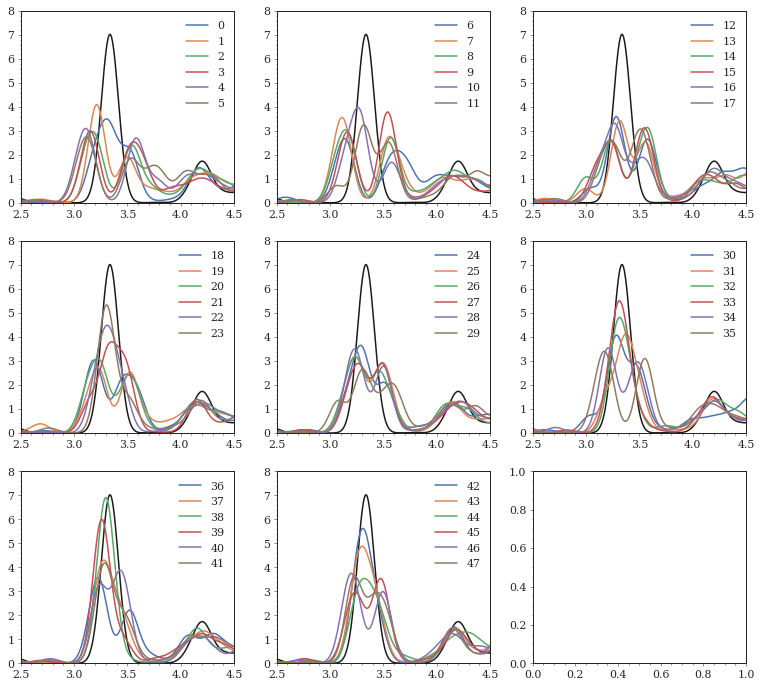

In [25]:
fig, axs = plt.subplots(3, 3, figsize=(13, 12))

energy = data0K_is0[:,0]

axs = axs.ravel()

for i in range(1, 9):
    axs[i-1].plot(energy, data0K_is0[:, 1], c='k')
    for j, data in enumerate([data[:, 1] for data in data350K_is0_md][(i-1)*6:(i)*6]):
        axs[i-1].plot(energy, data, label=(i-1)*6+j)
    axs[i-1].set_xlim(2.5, 4.5)
    axs[i-1].set_ylim(0, 8)
    axs[i-1].legend()

In [26]:
import matplotlib.pyplot as plt

#plt.style.use("bmh")
plt.rcParams.update({#"figure.figsize" : (12, 8),
                     "axes.facecolor" : "white",
                     #"axes.edgecolor":  "black"
                     })

Text(0.5, 0.915, 'MD individual samples: Optical spectrum')

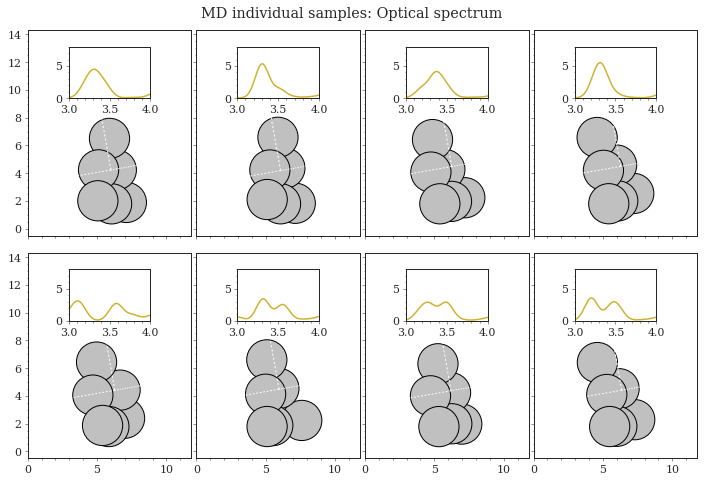

In [27]:
n_axes = 4
wspace = 0.03
hspace = 0.05

fig, axs = plt.subplots(2, 
                        n_axes, 
                        figsize=(3*n_axes, 4*2), 
                        sharey=True,
                        sharex=True, 
                        gridspec_kw={'wspace': wspace,
                                     'hspace': hspace}
                            )

sample_indexes = [[23, 24, 32, 34], [5, 14, 28, 35]]
path_MD = lambda isomer, n: path_opt_spc_dft +'/MD/Ag6_{:d}/index_{:d}/'.format(isomer+1, n)

for i in range(2):
    for ax, sample in zip(axs[i][:], sample_indexes[i]):
        plot_sample_and_optics(path_MD, 0, sample, ax, color=methods_color['MD'])
        ax.set_ylim(ymin=-0.5)

fig.suptitle('MD individual samples: Optical spectrum', x=0.5, y=0.915 )

# ab-flowMC SAMPLES

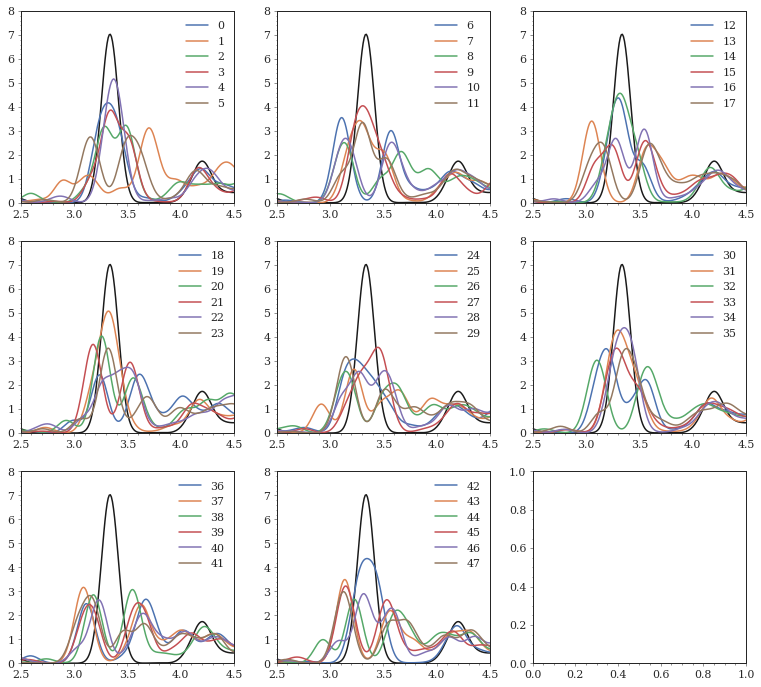

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(13, 12))

energy = data0K_is0[:,0]

axs = axs.ravel()

for i in range(1, 9):
    axs[i-1].plot(energy, data0K_is0[:, 1], c='k')
    for j, data in enumerate([data[:, 1] for data in data350K_is0_mlp][(i-1)*6:(i)*6]):
        axs[i-1].plot(energy, data, label=(i-1)*6+j)
    axs[i-1].set_xlim(2.5, 4.5)
    axs[i-1].set_ylim(0, 8)
    axs[i-1].legend()

Text(0.5, 0.915, 'ab-flowMC individual samples: Optical spectrum')

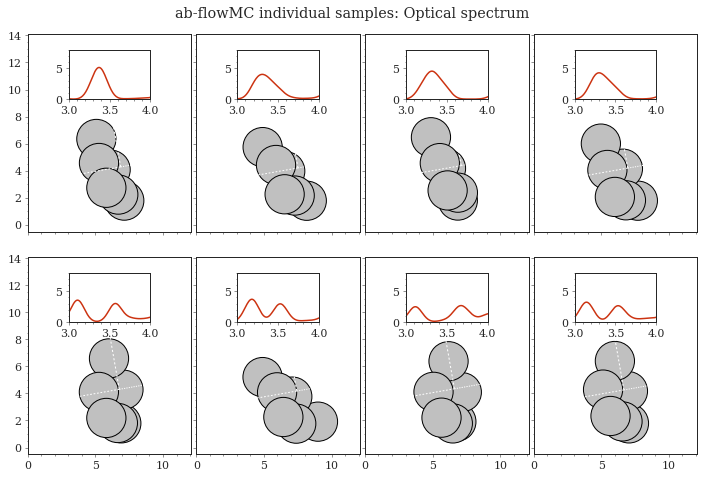

In [29]:
n_axes = 4
wspace = 0.03
hspace = 0.05

fig, axs = plt.subplots(2, 
                        n_axes, 
                        figsize=(3*n_axes, 4*2), 
                        sharey=True,
                        sharex=True, 
                        gridspec_kw={'wspace': wspace,
                                     'hspace': hspace}
                            )

sample_indexes = [[4, 9, 14, 31], [6, 21, 36, 45]]
path_mlp = lambda isomer, n: path_opt_spc_mlp +'/is{:d}_{:d}/sample_{:d}/'.format(isomer, 
                                                                                  simulation_idxs[methods[0]]['ab-flowMC'][isomer], n)

for i in range(2):
    for ax, sample in zip(axs[i][:], sample_indexes[i]):
        plot_sample_and_optics(path_mlp, 0, sample, ax, color=methods_color['ab-flowMC'])
        ax.set_ylim(ymin=-0.5)

fig.suptitle('ab-flowMC individual samples: Optical spectrum', x=0.5, y=0.915 )